# 05 · 워크트리: 혼돈 없는 병렬화

**구성요소:** 워크트리(worktree).

**핵심 아이디어**

> "두 에이전트가 같은 파일을 같은 시각에 고치면 병합 지옥이 온다. git 워크트리는 각 에이전트에게 히스토리는 공유하되 작업 파일은 공유하지 않는 자기만의 작업 디렉터리를 준다."

**문제 설정** — 저장소 하나에 에이전트 여럿을 동시에 돌린다. 각 에이전트는 기능 파일을 하나 추가하고, 그 사실을 공유 레지스트리 파일에 한 줄로 등록해야 한다.

- **공유 작업 디렉터리(shared working tree) 하나만 쓰면** 에이전트들의 레지스트리 편집이 서로를 덮어쓴다. 마지막 쓰기가 이기고, 앞선 작업은 사라진다.
- **에이전트마다 git 워크트리를 주고 마지막에 병합하면** 모든 에이전트의 작업이 살아남는다.

**측정 대상** — **통합률(integration rate)**, 즉 최종 공유 파일에 남아 있는 레지스트리 항목의 비율이다. 두 방식을 이 하나의 지표로 나란히 잰다. 워크트리라는 구성요소가 존재하는 이유가 바로 이 "처리량과 정확성" 지표이기 때문이다.

**역할 분담** — 기능 코드는 모델이 쓰고, 격리는 git 이 제공한다. 시험 대상은 모델의 능력이 아니라 **에이전트들이 상태를 나눠 쓰는 방식**이다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

============================================== Setup ===============================================

-------------------------------------------- 엔진 health ---------------------------------------------
{
  "provider": "openai",
  "model": "gpt-5.6-luna",
  "base_url": "(\uacf5\uc2dd \uc5d4\ub4dc\ud3ec\uc778\ud2b8)",
  "reply": "ready",
  "deterministic": true,
  "cost_usd": "$0.0000",
  "resolved_by": "localho

*에이전트마다 히스토리를 공유하는 자기 워크트리를 갖는다. 병합이 모든 작업을 통합한다*

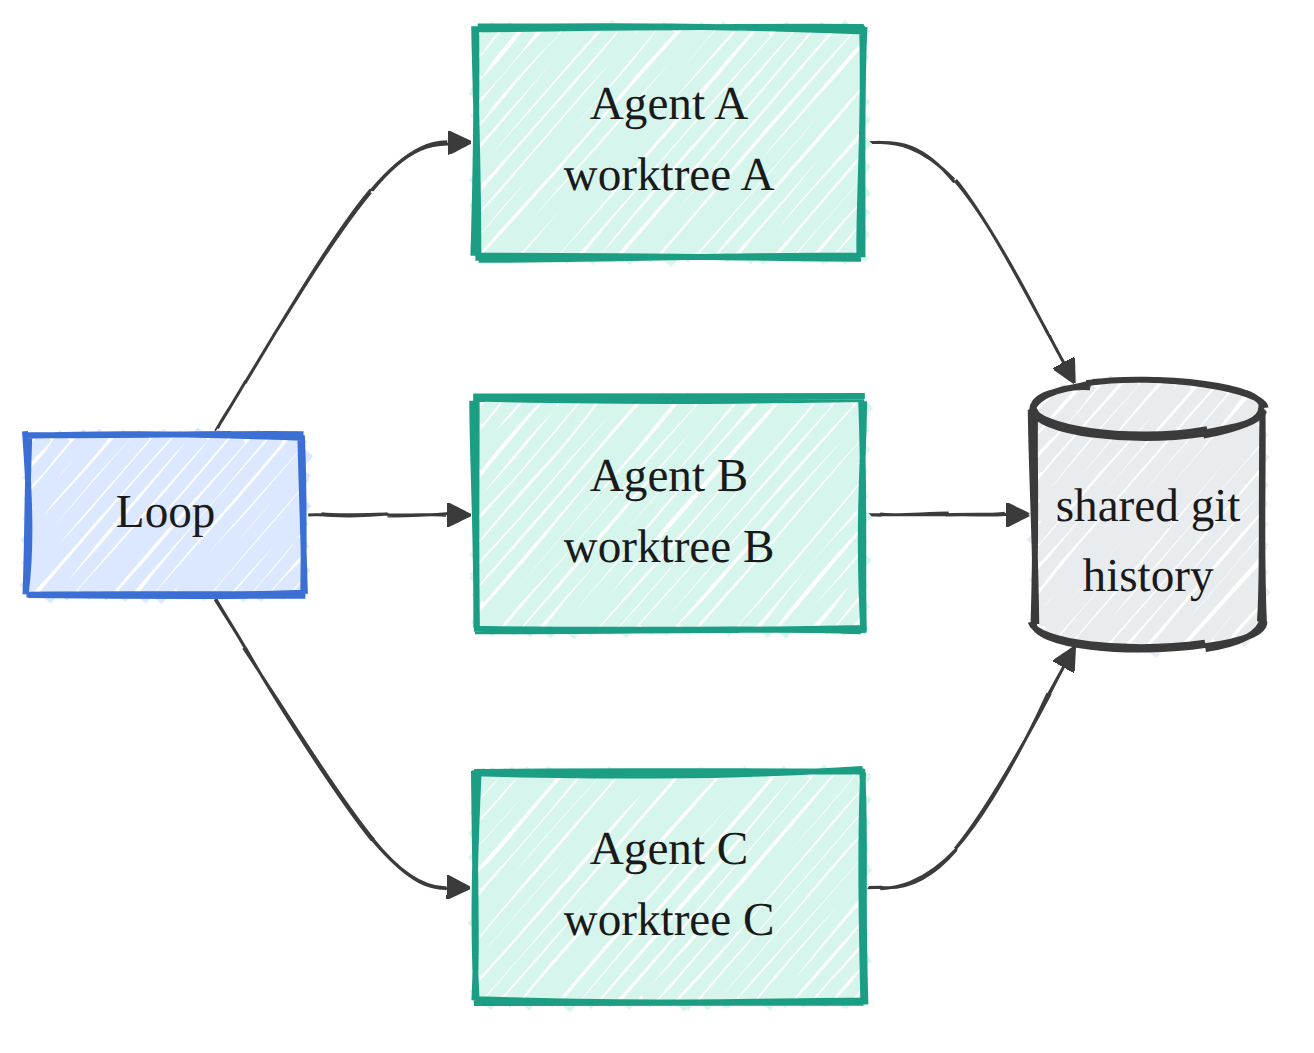

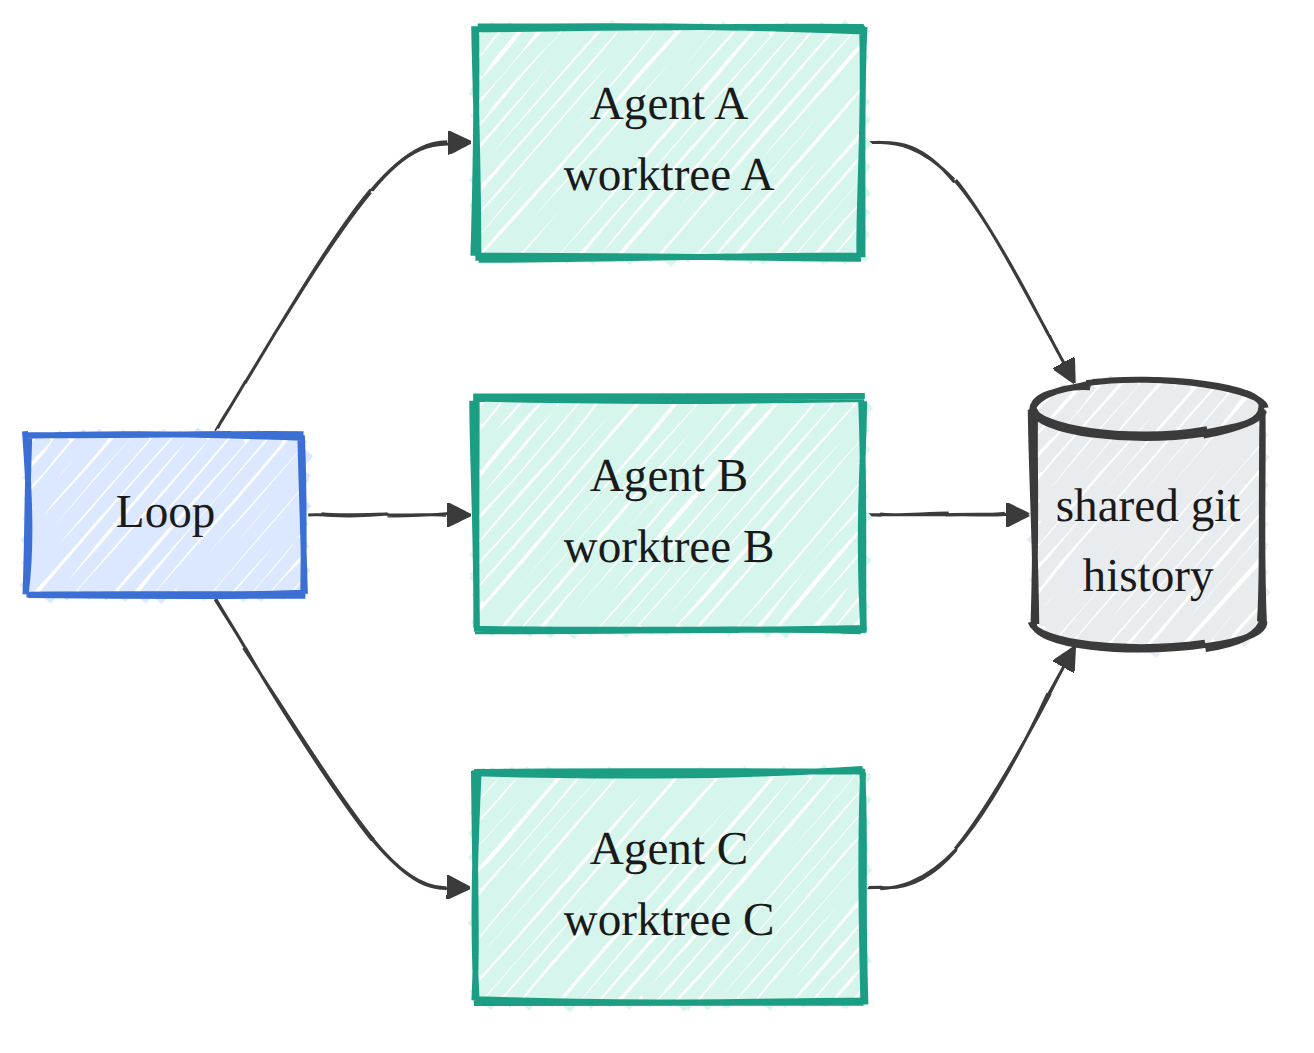

In [1]:
import os
import sys
import shutil
import subprocess
import tempfile
import time

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, agents, plotting, runlog, runtime
from common.llm import LLM

# ── 실험 상수 ─────────────────────────────────────────────────────
# 에이전트 6개: 한 저장소에 동시에 붙는 수다. 6분의 1이라는 생존율이
#   눈으로 읽힐 만큼 작으면서(약 17퍼센트), 워크트리를 6벌 만들어도
#   임시 디렉터리와 GPU 예산이 감당되는 크기다.
N_AGENTS = 6

# 실행 환경 자동 판별 (로컬 vLLM 우선, 없으면 OpenAI API)
rt = runtime.bootstrap()

llm = LLM()
show.head("Setup")
show.show_dict(llm.health(), "엔진 health")
show.diagram("worktrees", "에이전트마다 히스토리를 공유하는 자기 워크트리를 갖는다. 병합이 모든 작업을 통합한다")


def git(args, cwd):
    """git 명령을 cwd 에서 실행한다.

    capture_output=True 가 핵심이다. 병합 결과의 stdout/stderr 에서
    'CONFLICT' 문자열을 검사해야 하는데, 출력을 흘려보내면 그 신호를 잃는다.
    """
    return subprocess.run(["git"] + args, cwd=cwd, capture_output=True, text=True)


def new_repo():
    """빈 저장소를 만들고 레지스트리 초기 상태를 커밋한다.

    A안과 B안이 글자 하나까지 같은 출발점에서 시작해야 두 통합률의
    차이를 '격리 유무' 하나에 귀속시킬 수 있다.
    """
    d = tempfile.mkdtemp(prefix="wt_")
    git(["init", "-q"], d)
    git(["config", "user.email", "loop@example.com"], d)
    git(["config", "user.name", "loop"], d)
    # ⚠️ 함정: 서명 설정이 켜진 환경에서는 commit 이 키를 찾지 못해 실패하고,
    #    -q 때문에 그 실패가 눈에 띄지 않는다. 그러면 B안의 브랜치가 텅 빈
    #    채로 병합되어 "워크트리는 효과가 없다" 는 엉뚱한 결론이 나온다.
    #    임시 저장소에서는 반드시 꺼 둔다.
    git(["config", "commit.gpgsign", "false"], d)
    with open(os.path.join(d, "registry.py"), "w") as f:
        # "FEATURES = [" 바로 다음 줄이 여섯 에이전트가 모두 겨누는 단 하나의
        # 앵커다. 충돌 지점을 이렇게 좁게 설계해야 손실을 정확히 셀 수 있다.
        f.write("# central registry of installed features\nFEATURES = [\n]\n")
    git(["add", "-A"], d)
    git(["commit", "-q", "-m", "init"], d)
    return d

## 에이전트들이 할 일

각 에이전트는 작은 기능을 하나 구현하고(코드는 모델이 실제로 쓴다), 공유 `registry.py` 에 한 줄을 추가해 그 기능을 등록해야 한다. **레지스트리 편집이 충돌 지점이다.**


In [2]:
# ── 여섯 에이전트의 작업물 ─────────────────────────────────────────
# 태스크는 일부러 서로 겹치지 않게 골랐다. 기능 파일끼리는 충돌할 이유가
# 전혀 없고, 오직 registry.py 의 한 줄만 겹친다. 이 비대칭이 실험 설계의
# 전부다 — 손실이 나온다면 그것은 공유 상태 한 곳에서만 나와야 한다.
TASKS = [
    "a function `slugify(s)` that lowercases and hyphenates a string",
    "a function `clamp(x, lo, hi)` that clamps x to the range",
    "a function `chunk(lst, n)` that splits a list into n-sized chunks",
    "a function `flatten(xs)` that flattens one level of nesting",
    "a function `dedupe(xs)` that removes duplicates preserving order",
    "a function `is_prime(n)` returning True if n is prime",
]
TASKS = TASKS[:N_AGENTS]
features = []
for i, t in enumerate(TASKS):
    # temperature=0.0 — A안과 B안이 글자 하나까지 같은 코드를 쓰게 만든다.
    # 생성 결과가 두 방식에서 달라지면 통합률 차이가 격리 때문인지 코드
    # 때문인지 가를 수 없다. 여기서 코드는 처치 변수가 아니라 상수다.
    code, _ = agents.single_shot(llm, type("P", (), {"prompt": f"Write {t}. Return only the function.", "kind": "asserts", "entry_point": ""})(), temperature=0.0, label="feature")
    name = f"feature_{i}"
    # register_line 은 여섯 에이전트가 전부 같은 앵커에 밀어 넣을 한 줄이다.
    features.append({"i": i, "name": name, "code": code, "register_line": f'    "{name}",\n'})
    print(f"  agent {i}: wrote {name} ({len(code)} chars)")


def integration_rate(repo):
    """통합률: 여섯 항목 중 최종 registry.py 에 실제로 남아 있는 비율.

    ⚠️ 함정: 이 지표를 "기능 파일이 몇 개 생겼는가" 로 재면 두 방식 모두
    100퍼센트가 나온다. 기능 파일은 경로가 서로 달라 애초에 충돌하지
    않기 때문이다. 측정 대상을 잘못 고르면 손실이 통째로 보이지 않는다.
    공유 상태를 재는 지표만이 격리의 효과를 드러낸다.
    """
    reg = open(os.path.join(repo, "registry.py")).read()
    present = sum(1 for f in features if f'"{f["name"]}"' in reg)
    return present / len(features), present

  agent 0: wrote feature_0 (334 chars)
  agent 1: wrote feature_1 (100 chars)
  agent 2: wrote feature_2 (147 chars)
  agent 3: wrote feature_3 (72 chars)
  agent 4: wrote feature_4 (123 chars)
  agent 5: wrote feature_5 (316 chars)


  agent 1: wrote feature_1 (52 chars)


  agent 2: wrote feature_2 (120 chars)


  agent 3: wrote feature_3 (72 chars)


  agent 4: wrote feature_4 (174 chars)


  agent 5: wrote feature_5 (272 chars)


## A안: 공유 작업 디렉터리 하나 (격리 없음)

각 에이전트가 **독립적으로** 원본 레지스트리를 읽고, "원본 + 자기 줄" 을 되쓴다. 전부 같은 내용에서 출발해 같은 파일을 덮어쓰므로, **마지막 에이전트의 레지스트리 항목만 살아남는다.** 유실 갱신, 곧 병렬 충돌 실패다.


In [3]:
# ── A안: 공유 작업 디렉터리 (격리 없음) ────────────────────────────
repo_a = new_repo()

# ⚠️ 함정: original 을 루프 '밖에서' 한 번만 읽는다. 이것이 "여섯이 동시에
#    읽었다" 는 상황의 모형이다. 실수로 루프 안에서 매번 파일을 다시 읽으면
#    편집이 순차적으로 누적되어 손실이 사라지고, 재현하려던 경쟁 조건 자체가
#    사라진다. 동시성 버그를 재현하는 코드는 '언제 읽는가' 가 전부다.
original = open(os.path.join(repo_a, "registry.py")).read()

for f in features:
    # 기능 파일 쓰기 (각자 자기 경로, 충돌 없음)
    with open(os.path.join(repo_a, f["name"] + ".py"), "w") as fh:
        fh.write(f["code"])
    # 각 에이전트는 ORIGINAL 내용을 기준으로 공유 레지스트리를 편집한다
    # (= 동시 읽기). 여기서 계산된 new_reg 에는 자기 줄만 들어 있다.
    new_reg = original.replace("FEATURES = [\n", "FEATURES = [\n" + f["register_line"])
    with open(os.path.join(repo_a, "registry.py"), "w") as fh:
        fh.write(new_reg)  # 마지막 쓰기가 이긴다 — 앞선 다섯 줄이 여기서 소멸한다

rate_a, present_a = integration_rate(repo_a)
show.sub("공유 트리의 registry.py")
show.code(open(os.path.join(repo_a, "registry.py")).read(), "최종 레지스트리 (공유 트리)", max_chars=300)
show.metric("통합률 (공유 트리)", rate_a)
show.metric("보존된 항목", f"{present_a}/{len(features)}")


---------------------------------------- 공유 트리의 registry.py ----------------------------------------

----------------------------------------- 최종 레지스트리 (공유 트리) -----------------------------------------
  | # central registry of installed features
  | FEATURES = [
  |     "feature_5",
  | ]
  통합률 (공유 트리)                      0.1667
  보존된 항목                           1/6


## B안: 에이전트마다 git 워크트리, 그리고 병합

각 에이전트는 자기 브랜치 위의 **자기 `git worktree`** 에서 일하고, 거기서 레지스트리를 편집하고, 커밋한다. 그다음 브랜치들을 병합하면 모든 에이전트의 한 줄 추가가 통합된다. git 이 겹치지 않는 조각(hunk)들을 병합해 주기 때문이다. **모든 작업이 살아남는다.**


In [4]:
# ── B안: 에이전트마다 워크트리 + 병합 ──────────────────────────────
repo_b = new_repo()
original_b = open(os.path.join(repo_b, "registry.py")).read()
wt_root = tempfile.mkdtemp(prefix="wts_")
t0 = time.time()  # 격리의 대가(병합 시간)를 재기 위한 시작점

for f in features:
    wt = os.path.join(wt_root, f["name"])
    # worktree add -b: 새 브랜치와 그 브랜치의 별도 체크아웃을 동시에 만든다.
    # 히스토리(.git 객체)는 공유하고 작업 파일만 분리된다 — 이것이 격리의 실체다.
    git(["worktree", "add", "-q", "-b", f["name"], wt], repo_b)
    with open(os.path.join(wt, f["name"] + ".py"), "w") as fh:
        fh.write(f["code"])
    # A안과 완전히 같은 문자열 치환이다. 바뀐 것은 '어디에 쓰는가' 하나뿐이다.
    new_reg = original_b.replace("FEATURES = [\n", "FEATURES = [\n" + f["register_line"])
    with open(os.path.join(wt, "registry.py"), "w") as fh:
        fh.write(new_reg)
    git(["add", "-A"], wt)
    # 커밋해야 브랜치에 기록으로 남는다. 커밋하지 않은 워크트리의 변경은
    # 병합 대상이 아니므로, 여기서 커밋을 빠뜨리면 격리가 무의미해진다.
    git(["commit", "-q", "-m", f"add {f['name']}"], wt)

# 모든 브랜치를 main 으로 병합한다. 여섯 에이전트가 같은 앵커에 줄을 넣었으므로
# git 은 공유 파일에서 충돌을 보고한다. 결정적인 점은 그 충돌이 '표면화' 된다는
# 것이다(조용한 소실이 아니라). 그래서 모든 에이전트의 항목을 합집합으로 묶어
# 해결할 수 있다. 워크트리 워크플로가 가능하게 만드는 의미론적 병합이며,
# 어떤 에이전트의 작업도 잃지 않는다.
import re as _re


def _union_registry():
    """충돌 해결 규칙: 모든 브랜치의 feature_N 항목을 모아 합집합을 쓴다.

    현재 작업본과 여섯 브랜치의 registry.py 를 모두 훑는다. 이 레지스트리는
    '순서가 의미를 갖지 않는 집합' 이라서 합집합이 올바른 해결이다.
    """
    cur = open(os.path.join(repo_b, "registry.py")).read()
    found = set(_re.findall(r'"(feature_\d+)"', cur))
    for f in features:
        # git show <브랜치>:<경로> — 체크아웃하지 않고 그 브랜치의 파일을 읽는다.
        inc = git(["show", f"{f['name']}:registry.py"], repo_b).stdout
        found |= set(_re.findall(r'"(feature_\d+)"', inc))
    ordered = sorted(found, key=lambda x: int(x.split("_")[1]))
    body = "# central registry of installed features\nFEATURES = [\n" + "".join(f'    "{x}",\n' for x in ordered) + "]\n"
    with open(os.path.join(repo_b, "registry.py"), "w") as fh:
        fh.write(body)


conflicts = 0
for f in features:
    r = git(["merge", "--no-edit", f["name"]], repo_b)
    # ⚠️ 함정: git merge 는 충돌해도 예외를 던지지 않는다. 반환 코드와 출력
    #    문자열을 직접 검사하지 않으면 충돌을 못 본 채 다음 병합으로 넘어가고,
    #    작업 트리에 <<<<<<< 마커가 남은 파일이 그대로 커밋된다. 병합을
    #    자동화할 때 가장 흔한 사고다.
    if "CONFLICT" in (r.stdout + r.stderr):
        conflicts += 1
        _union_registry()  # 표면화된 충돌 → 전 항목 합집합 (작업 손실 없음)
        git(["add", "registry.py"], repo_b)
        git(["commit", "--no-edit", "-q"], repo_b)

elapsed_b = time.time() - t0

# 워크트리 정리. 지우지 않으면 .git/worktrees 에 등록이 남아 다음 실행에서
# 같은 이름의 브랜치를 만들 때 실패한다.
for f in features:
    git(["worktree", "remove", "--force", os.path.join(wt_root, f["name"])], repo_b)

rate_b, present_b = integration_rate(repo_b)
show.sub("워크트리+병합의 registry.py")
show.code(open(os.path.join(repo_b, "registry.py")).read(), "최종 레지스트리 (워크트리)", max_chars=400)
show.metric("통합률 (워크트리)", rate_b)
show.metric("보존된 항목", f"{present_b}/{len(features)}")
show.metric("자동 해결한 병합 충돌", conflicts)


--------------------------------------- 워크트리+병합의 registry.py ---------------------------------------

----------------------------------------- 최종 레지스트리 (워크트리) ------------------------------------------
  | # central registry of installed features
  | FEATURES = [
  |     "feature_0",
  |     "feature_1",
  |     "feature_2",
  |     "feature_3",
  |     "feature_4",
  |     "feature_5",
  | ]
  통합률 (워크트리)                       1.0000
  보존된 항목                           6/6
  자동 해결한 병합 충돌                     5


## 비교와 시각화


  통합률: 워크트리 vs 공유 트리
    baseline : 0.1667
    treatment: 1.0000
    delta    : +0.8333  (+500.0 percent)  [up, improvement]


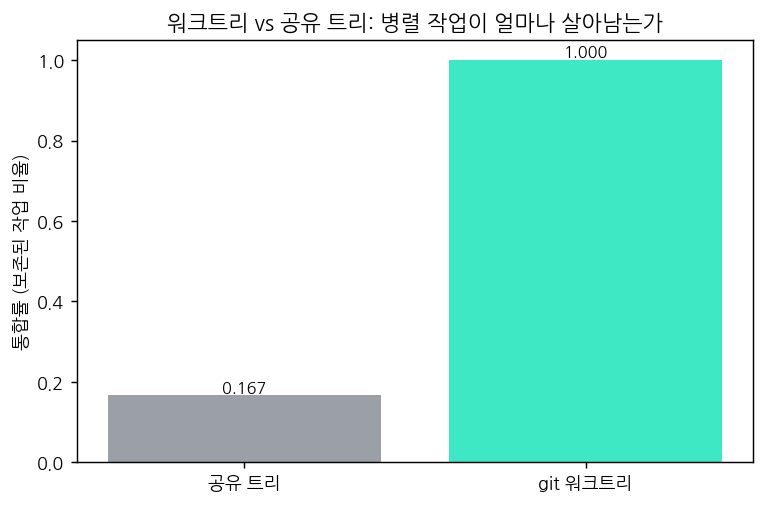

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/05_worktrees.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/05_worktrees.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (worktrees: report-only, ~1610 tokens)


In [5]:
d = show.compare("통합률: 워크트리 vs 공유 트리", rate_a, rate_b)
# 막대 두 개면 충분하다. 이 실험의 주장은 곡선이 아니라 격차 하나이기 때문이다.
plotting.ab_bar("05_worktrees", ["공유 트리", "git 워크트리"], [rate_a, rate_b],
                "통합률 (보존된 작업 비율)", "워크트리 vs 공유 트리: 병렬 작업이 얼마나 살아남는가")

runlog.save_metrics("05_worktrees", {"notebook": "05_worktrees", "n_agents": N_AGENTS,
                                      "provider": llm.provider,   # 한국어판 추가: 어느 백엔드의 수치인지 기록
                                      "model": llm.model,
                                      "integration_shared_tree": rate_a, "integration_worktrees": rate_b,
                                      # 충돌 수를 함께 저장한다. 통합률만 보면 "충돌이 없어서 좋았다" 는
                                      # 정반대의 오해가 가능하다. 5건의 충돌이 성공의 증거다.
                                      "conflicts_resolved": conflicts, "delta": d})
runlog.log_run(pattern="worktrees", duration_s=elapsed_b, items_found=N_AGENTS,
               actions_taken=present_b, escalations=0, tokens_estimate=llm.usage.total_tokens, outcome="report-only")

# 정리: 임시 저장소와 워크트리 루트를 지운다. tempfile 로 만들었으므로
# 남겨 두면 재실행 때마다 디스크에 쌓인다.
for d_ in (repo_a, repo_b, wt_root):
    shutil.rmtree(d_, ignore_errors=True)

## 이번 실행이 실제로 보여 준 것


In [6]:
show.head("이번 실행이 실제로 보여 준 것")
print(f"공유 작업 디렉터리 하나에서는 에이전트 {N_AGENTS}명 중 {present_a}명의 레지스트리 항목만 살아남았다")
print(f"(통합률 {rate_a:.0%}): 공유 파일에 대한 동시 편집이 서로를 덮어썼다.")
print(f"에이전트마다 git 워크트리를 주고 병합하면 {present_b}/{N_AGENTS} 가 살아남았다({rate_b:.0%}).")
print("각 에이전트가 자기 작업 디렉터리를 가졌고, git 이 겹치지 않는 변경을 병합했기 때문이다.")
print()
print("=> 이것이 워크트리 구성요소다: 격리가 병렬 충돌 실패를 막아 주므로,")
print("   저장소 하나에 에이전트 여럿을 동시에 돌리면서도 작업을 잃지 않는다.")


======================================== 이번 실행이 실제로 보여 준 것 =========================================
공유 작업 디렉터리 하나에서는 에이전트 6명 중 1명의 레지스트리 항목만 살아남았다
(통합률 17%): 공유 파일에 대한 동시 편집이 서로를 덮어썼다.
에이전트마다 git 워크트리를 주고 병합하면 6/6 가 살아남았다(100%).
각 에이전트가 자기 작업 디렉터리를 가졌고, git 이 겹치지 않는 변경을 병합했기 때문이다.

=> 이것이 워크트리 구성요소다: 격리가 병렬 충돌 실패를 막아 주므로,
   저장소 하나에 에이전트 여럿을 동시에 돌리면서도 작업을 잃지 않는다.
